# Figures 4 and 5: 4D-Var State Estimation and Analysis Skill

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib.ticker import AutoMinorLocator
import os

# =========================================================
# Read processed data
# =========================================================

# --- Existing PI-NPZ + Traditional-NPZ data ---
processed_dir = "../../data/processed_assimilation_data"

df_xb_distances = pd.read_csv(
    os.path.join(processed_dir, "background_state_distances.csv")
)

df_flat_original = pd.read_csv(
    os.path.join(processed_dir, "assimilation_metrics.csv")
)

df_skills_aggregated = pd.read_csv(
    os.path.join(processed_dir, "analysis_skills_aggregated.csv")
)


# --- New NN-NPZ data ---
nn_processed_dir = "../../data/nn_processed_assimilation_data"

df_nn_flat = pd.read_csv(
    os.path.join(nn_processed_dir, "nn_assimilation_metrics.csv")
)


# =========================================================
# Combine assimilation metrics
# =========================================================

df_flat = pd.concat(
    [df_flat_original, df_nn_flat],
    ignore_index=True
)


# =========================================================
# Recreate derived columns for boxplots
# =========================================================

df_flat["log_runtime"] = np.log10(df_flat["runtime"])

df_flat["jo_jb_ratio"] = (
    df_flat["jo_a"] / df_flat["jb_a"]
)

df_flat["log_jo_jb_ratio"] = np.log10(
    df_flat["jo_jb_ratio"]
)

df_flat["pct_drop_J_100"] = (
    100 * df_flat["pct_drop_J"]
)


# =========================================================
# Create plotting-ready format
# =========================================================

metrics_normal = [
    "runtime",
    "pct_drop_J_100",
    "log_jo_jb_ratio"
]

df_long_normal = df_flat.melt(
    id_vars=["method", "dataset"],
    value_vars=metrics_normal,
    var_name="metric",
    value_name="value"
)

df_long_normal["metric"] = df_long_normal["metric"].replace({
    "runtime": "Computational Time (s)",
    "pct_drop_J_100": "Cost Function Reduction (%)",
    "log_jo_jb_ratio": "log$_{10}(J_o/J_b)$"
})


# =========================================================
# Existing skill data
# NN-NPZ will be added after its skill data are processed
# =========================================================

df_skills_timeseries = df_skills_aggregated[
    df_skills_aggregated["time_days"] >= 0
]

df_skills_global = df_skills_aggregated[
    df_skills_aggregated["time_days"] == -1
]


# =========================================================
# Checks
# =========================================================

print("✓ Data loaded successfully")
print(f"  - Original assimilation metrics: {df_flat_original.shape[0]} rows")
print(f"  - NN-NPZ assimilation metrics:   {df_nn_flat.shape[0]} rows")
print(f"  - Combined assimilation metrics: {df_flat.shape[0]} rows")
print(f"  - Skill time series:             {df_skills_timeseries.shape[0]} rows")
print(f"  - Background distances:          {df_xb_distances.shape[0]} rows")

print("\nAssimilation rows by method:")
print(df_flat.groupby(["method", "dataset"]).size())

✓ Data loaded successfully
  - Original assimilation metrics: 60000 rows
  - NN-NPZ assimilation metrics:   30000 rows
  - Combined assimilation metrics: 90000 rows
  - Skill time series:             2018 rows
  - Background distances:          30000 rows

Assimilation rows by method:
method           dataset       
NN-NPZ           baseline          10000
                 field_informed    10000
                 irreg_sparse      10000
PI-NPZ           baseline          10000
                 field_informed    10000
                 irreg_sparse      10000
Traditional-NPZ  baseline          10000
                 field_informed    10000
                 irreg_sparse      10000
dtype: int64


In [4]:
# Runtime summary and speedup relative to Traditional-NPZ
df_runtime = df_long_normal[
    df_long_normal["metric"] == "Computational Time (s)"
]

runtime_stats = (
    df_runtime.groupby(["method", "dataset"])["value"]
    .describe()[["mean", "50%", "min", "max"]]
)
print(runtime_stats)

means = df_runtime.groupby(["dataset", "method"])["value"].mean().unstack()
speedup = means[["PI-NPZ", "NN-NPZ"]].rdiv(means["Traditional-NPZ"], axis=0)
print("\nSpeedup over Traditional-NPZ (ratio of means):")
print(speedup.round(2))

                                    mean       50%       min        max
method          dataset                                                
NN-NPZ          baseline        1.200097  1.171354  0.841323   2.797795
                field_informed  0.994780  0.982580  0.793604   2.094366
                irreg_sparse    1.590634  1.549187  1.164551   2.995659
PI-NPZ          baseline        1.207050  1.165132  0.864620   1.962600
                field_informed  0.934212  0.926223  0.777786   1.697510
                irreg_sparse    1.638319  1.598678  1.166872   3.290856
Traditional-NPZ baseline        7.606708  7.607050  6.904687   8.390848
                field_informed  6.151213  6.113865  5.525990   7.272849
                irreg_sparse    9.729315  9.728676  8.638897  10.744238

Speedup over Traditional-NPZ (ratio of means):
method          PI-NPZ  NN-NPZ
dataset                       
baseline          6.30    6.34
field_informed    6.58    6.18
irreg_sparse      5.94    6.12


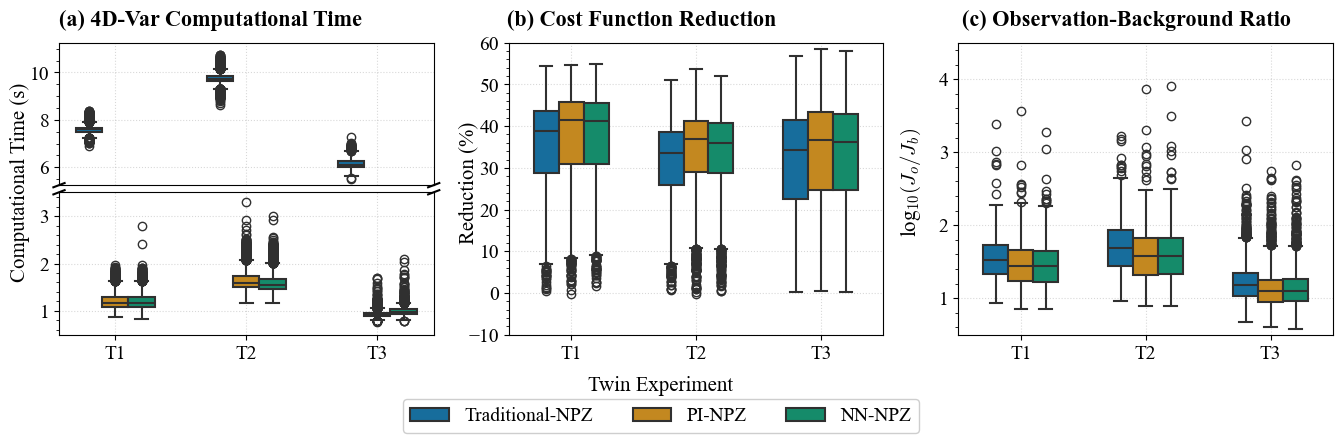

In [5]:
# =========================================================
# Global Figure Settings
# =========================================================

# --- Typography ---
font_size_base   = 14
font_size_tick   = 14
font_size_label  = 15
font_size_title  = 16
font_size_legend = 14

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rcParams['font.size'] = font_size_base
plt.rcParams['axes.labelsize'] = font_size_label
plt.rcParams['axes.titlesize'] = font_size_title
plt.rcParams['xtick.labelsize'] = font_size_tick
plt.rcParams['ytick.labelsize'] = font_size_tick
plt.rcParams['legend.fontsize'] = font_size_legend


# =========================================================
# Colors / Method Ordering
# =========================================================

trad_npz_color = "#0173B2"   # Traditional-NPZ (blue)
pinn_color     = "#DE8F05"   # PI-NPZ (orange)
nn_color       = "#029E73"   # NN-NPZ (bluish green)

method_palette = {
    "Traditional-NPZ": trad_npz_color,
    "PI-NPZ": pinn_color,
    "NN-NPZ": nn_color,
}

method_order = [
    "Traditional-NPZ",
    "PI-NPZ",
    "NN-NPZ",
]


# =========================================================
# Runtime subset
# =========================================================

df_runtime = df_long_normal[
    df_long_normal["metric"] == "Computational Time (s)"
]


# =========================================================
# Create Figure
# =========================================================

fig = plt.figure(figsize=(14, 4))

gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    left=0.07,
    right=0.98,
    top=0.88,
    bottom=0.15,
    wspace=0.2,
    hspace=0.05
)

panel_labels = ["(a)", "(b)", "(c)"]


# =========================================================
# (a) Assimilation Runtime — Broken Axis
# =========================================================

ax_top = fig.add_subplot(gs[0, 0])

sns.boxplot(
    data=df_runtime,
    x="dataset",
    y="value",
    hue="method",
    hue_order=method_order,
    palette=method_palette,
    width=0.6,
    linewidth=1.5,
    ax=ax_top
)

ax_top.set_ylim(5.25, 11.25)
ax_top.set_ylabel("")
ax_top.set_xlabel("")

ax_top.tick_params(
    labelbottom=False,
    bottom=False,
    labelsize=font_size_tick
)

ax_top.grid(
    True,
    linestyle=":",
    alpha=0.3,
    color="gray"
)

ax_top.yaxis.set_minor_locator(AutoMinorLocator())

if ax_top.get_legend() is not None:
    ax_top.get_legend().remove()


# --- Bottom portion of broken axis ---

ax_bottom = fig.add_subplot(gs[1, 0], sharex=ax_top)

sns.boxplot(
    data=df_runtime,
    x="dataset",
    y="value",
    hue="method",
    hue_order=method_order,
    palette=method_palette,
    width=0.6,
    linewidth=1.5,
    ax=ax_bottom
)

ax_bottom.set_ylim(0.5, 3.5)
ax_bottom.set_xlabel("")
ax_bottom.set_ylabel("")

ax_bottom.set_xticks(range(3))
ax_bottom.set_xticklabels(["T1", "T2", "T3"])

ax_bottom.tick_params(
    labelsize=font_size_tick
)

ax_bottom.grid(
    True,
    linestyle=":",
    alpha=0.3,
    color="gray"
)

ax_bottom.yaxis.set_minor_locator(AutoMinorLocator())


# Save legend handles before removing axis legend
handles, labels = ax_bottom.get_legend_handles_labels()

if ax_bottom.get_legend() is not None:
    ax_bottom.get_legend().remove()


# --- Broken-axis marks ---

d = 0.015

for ax, pos in [(ax_bottom, 1), (ax_top, 0)]:

    kwargs = dict(
        transform=ax.transAxes,
        color="k",
        clip_on=False
    )

    ax.plot(
        (-d, +d),
        (pos - d, pos + d),
        **kwargs
    )

    ax.plot(
        (1 - d, 1 + d),
        (pos - d, pos + d),
        **kwargs
    )


# =========================================================
# (b) Cost Function Reduction
# =========================================================

metric_data = df_long_normal[
    df_long_normal["metric"] == "Cost Function Reduction (%)"
]

ax_b = fig.add_subplot(gs[:, 1])

sns.boxplot(
    data=metric_data,
    x="dataset",
    y="value",
    hue="method",
    hue_order=method_order,
    palette=method_palette,
    width=0.6,
    linewidth=1.5,
    ax=ax_b
)

ax_b.set_ylabel("")
ax_b.set_xlabel("")

ax_b.set_xticks(range(3))
ax_b.set_xticklabels(["T1", "T2", "T3"])

ax_b.tick_params(
    labelsize=font_size_tick
)

ax_b.grid(
    True,
    linestyle=":",
    alpha=0.3,
    color="gray"
)

ax_b.yaxis.set_minor_locator(AutoMinorLocator())
ax_b.set_ylim(-10, 60)

if ax_b.get_legend() is not None:
    ax_b.get_legend().remove()


# =========================================================
# (c) Observation-Background Ratio
# =========================================================

metric_data = df_long_normal[
    df_long_normal["metric"] == "log$_{10}(J_o/J_b)$"
]

ax_c = fig.add_subplot(gs[:, 2])

sns.boxplot(
    data=metric_data,
    x="dataset",
    y="value",
    hue="method",
    hue_order=method_order,
    palette=method_palette,
    width=0.6,
    linewidth=1.5,
    ax=ax_c
)

ax_c.set_ylabel("")
ax_c.set_xlabel("")

ax_c.set_xticks(range(3))
ax_c.set_xticklabels(["T1", "T2", "T3"])

ax_c.tick_params(
    labelsize=font_size_tick
)

ax_c.grid(
    True,
    linestyle=":",
    alpha=0.3,
    color="gray"
)

ax_c.yaxis.set_minor_locator(AutoMinorLocator())
ax_c.set_ylim(0.5, 4.5)

if ax_c.get_legend() is not None:
    ax_c.get_legend().remove()


# =========================================================
# Panel Titles
# =========================================================

fig.text(
    0.07,
    0.91,
    f"{panel_labels[0]} 4D-Var Computational Time",
    fontsize=font_size_title,
    fontweight="bold",
    ha="left",
    va="bottom"
)

fig.text(
    0.39,
    0.91,
    f"{panel_labels[1]} Cost Function Reduction",
    fontsize=font_size_title,
    fontweight="bold",
    ha="left",
    va="bottom"
)

fig.text(
    0.715,
    0.91,
    f"{panel_labels[2]} Observation-Background Ratio",
    fontsize=font_size_title,
    fontweight="bold",
    ha="left",
    va="bottom"
)


# =========================================================
# Figure-Level Y Labels
# =========================================================

fig.text(
    0.035,
    0.53,
    "Computational Time (s)",
    fontsize=font_size_label,
    va="center",
    rotation="vertical"
)

fig.text(
    0.355,
    0.53,
    "Reduction (%)",
    fontsize=font_size_label,
    va="center",
    rotation="vertical"
)

fig.text(
    0.67,
    0.53,
    "log$_{10}(J_o/J_b)$",
    fontsize=font_size_label,
    va="center",
    rotation="vertical"
)


# =========================================================
# Shared X Label
# =========================================================

fig.text(
    0.5,
    0.01,
    "Twin Experiment",
    fontsize=font_size_label,
    ha="center"
)


# =========================================================
# Shared Legend
# =========================================================

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    fontsize=font_size_legend,
    framealpha=0.95,
    bbox_to_anchor=(0.5, -0.12)
)

# =========================================================
# Save
# =========================================================

base_path = "../../figures/"
file_base = "fig4"

plt.savefig(
    f"{base_path}{file_base}.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
    format="pdf"
)

plt.show()

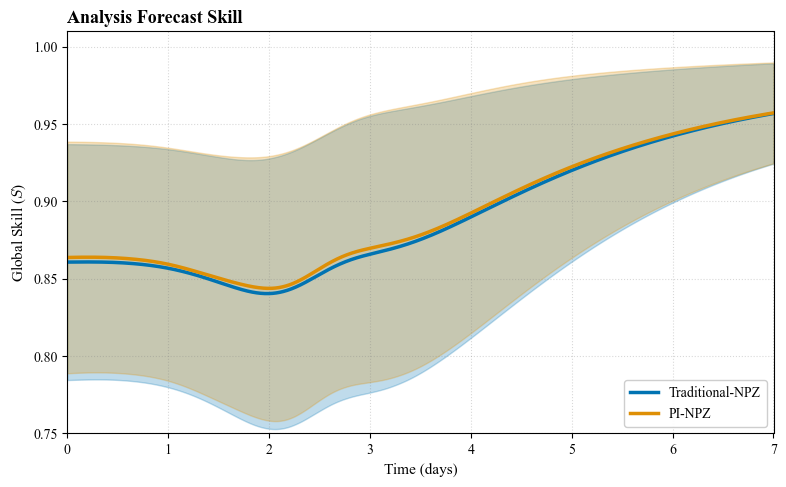

In [9]:
# Reset any settings left over from earlier cells (e.g., Figure 4)
plt.rcdefaults()

# Typography for JAMES publication
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False

# Axis and tick styling
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['text.color'] = 'black'

# Color scheme
colors = {"PI-NPZ": "#DE8F05", "Traditional-NPZ": "#0173B2"}

# === Single-panel figure ===
fig, ax = plt.subplots(figsize=(8, 5))

for method in ["Traditional-NPZ", "PI-NPZ"]:
    method_data = df_skills_timeseries[df_skills_timeseries["method"] == method]

    times = method_data["time_days"].values
    mean = method_data["skill_mean"].values
    std = method_data["skill_std"].values

    lower = np.clip(mean - std, 0.0, None)
    upper = np.minimum(mean + std, 1.0)

    ax.plot(times, mean, color=colors[method], linewidth=2.5, label=method)
    ax.fill_between(times, lower, upper, color=colors[method], alpha=0.25)

# Labels and formatting
ax.set_title("Analysis Forecast Skill", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Global Skill ($S$)")
ax.set_xlim(0, 7)
ax.set_ylim(0.75, 1.01)
ax.grid(True, linestyle=':', alpha=0.3, color='gray')
ax.legend(loc='lower right', framealpha=0.95)

plt.tight_layout()

# === Save ===
# plt.savefig(
#     "../../figures/fig5.pdf",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     format="pdf",
# )
plt.show()